In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv("ventas_consolidadas.csv")
print("dimesiones", df.shape)
df.head()

dimesiones (500, 7)


,Fecha,Ciudad,Canal,Producto,Cantidad,Precio_Unitario,Monto_Venta
0,2024-01-01,Barranquilla,Tienda,Arroz,5,2.76,13.80
1,2024-01-02,Cartagena,Online,Cereal,16,9.89,158.24
2,2024-01-03,Cali,Tienda,Huevos,6,9.70,58.20
3,2024-01-04,Cartagena,Online,Pan,8,1.54,12.32
4,2024-01-05,Cartagena,Distribuidor,Leche,18,9.59,172.62


In [7]:
x=df[["Cantidad","Precio_Unitario"]] ##Variable independiente
y=df["Monto_Venta"] #Variabl dependiente


In [8]:
#Entrenamiento y Prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Entrenamiento",x_train.shape,"Prueba",x_test.shape)


Entrenamiento (400, 2) Prueba (100, 2)


In [9]:
#Entrenar modelo
from sklearn.linear_model import LinearRegression
modelo=LinearRegression()
modelo.fit(x_train,y_train)
#La ecuacion siempre va ser y=B0+B1*X1+B2*X2
#X1(1 variable) X2(2 variable)
#Y= es el monto de venta B0("57") B1(5.75 + 9.86)
#B1(coeficiente1*la cantidad), B2(coefiente2*precio unitario)
print("intercepto",modelo.intercept_)
print("coeficientes",modelo.coef_)

intercepto -57.58521889507954
coeficientes [5.75445908 9.86395299]


In [10]:
#Predicciones
y_pred=modelo.predict(x_test)
print("reales",list(y_test[:5]))#muestra la informacion real en los montos de venta
print("predicciones",list(y_pred[:5])) #muestra las predicciones con base a la informacion que vamos a aportar

reales [106.5, 94.78, 25.32, 33.3, 8.22]
predicciones [np.float64(98.76573356669019), np.float64(89.7561699980044), np.float64(32.28123089508377), np.float64(36.88100343519964), np.float64(-5.535453937421906)]


In [11]:
#Evaluar
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
mse=np.sqrt(mean_squared_error(y_test,y_pred))#mse(error cuadratico medio)=valida si el modelo se ajusta o tiene diferencias
r2=r2_score(y_test,y_pred) #r2()cuanta variabilidad va tener la variable que queremos tener el conocimiento
print("mse",mse) #mse=promedio de las diferencias entre lo real y la  prediccion
print("r2",r2)   #1=predicion perfecta, 0=no se puede explicar nada ,valor negativo=no hay informacion clara

mse 13.139477007325995
r2 0.9013469656668395


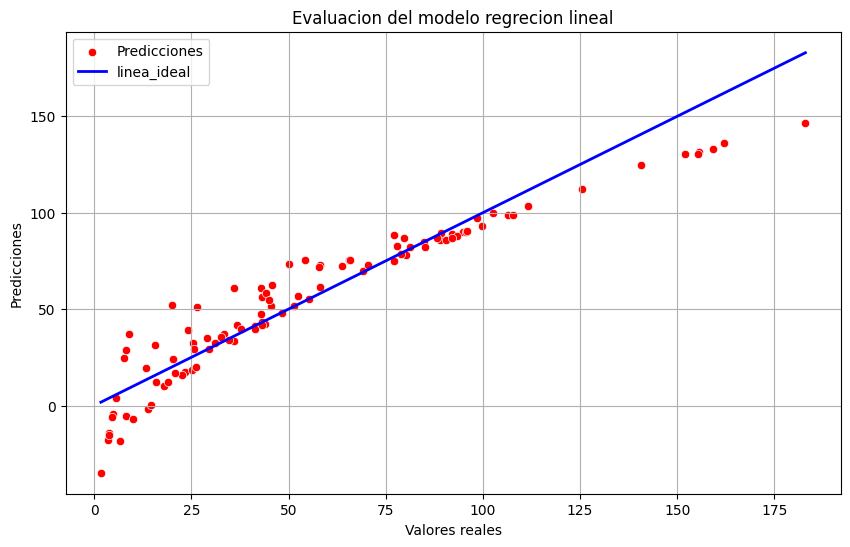

In [13]:
#Visualizacion de datos
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=y_pred,color="red",label="Predicciones")
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],color="blue",linewidth=2,label="linea_ideal")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Evaluacion del modelo regrecion lineal")
plt.legend()
plt.grid()
plt.show()